簡單記錄一下 這邊承襲了OU_NoTrain-2D BolbLine_betaSigmaConst使用的OU算法  
然後以spiral作為原始數據

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sample_p0_mix(n_points=2500):
    theta = np.sqrt(np.random.rand(n_points)) * 6 * np.pi # 角度
    r = 1 * theta 
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    data = np.stack([x, y], axis=1) + np.random.randn(n_points, 2) * 0.1
    return data

In [ ]:
beta = 1.0   #<<<<<<<<<<<<<<<<<<<
sigma = 5.0
t = 10
x0 = sample_p0_mix(n_points=2500)

mu_t = np.exp(-beta * t) * x0
var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
std_t = np.sqrt(var_t)
xt = mu_t + std_t * np.random.randn(*x0.shape)


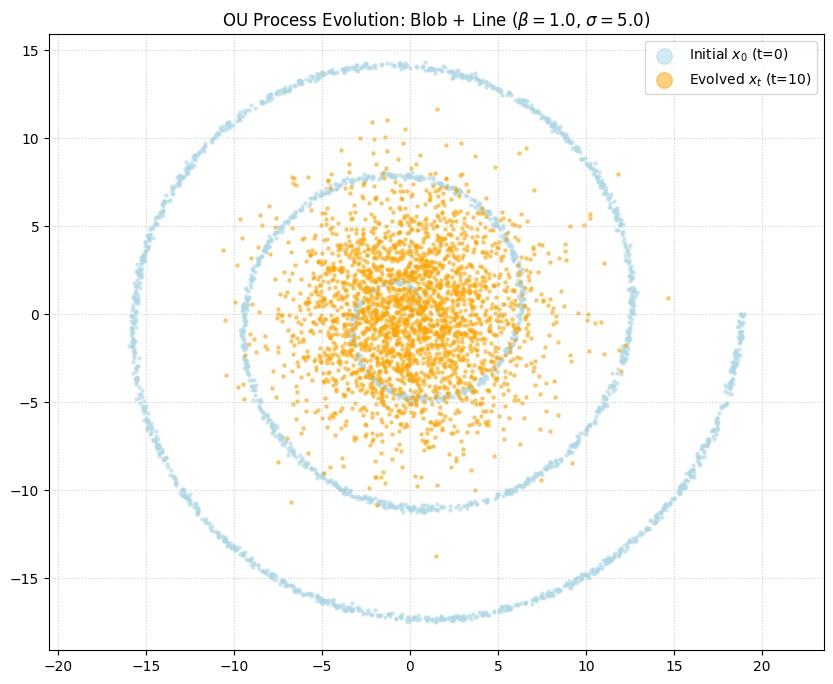

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(x0[:, 0], x0[:, 1], color='lightblue', s=5, alpha=0.5, label='Initial $x_0$ (t=0)')
plt.scatter(xt[:, 0], xt[:, 1], color='orange', s=5, alpha=0.5, label=f'Evolved $x_t$ (t={t})')

plt.title(fr'OU Process Evolution: Blob + Line ($\beta={beta}$, $\sigma={sigma}$)')
plt.legend(markerscale=5)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), 
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [ ]:
def train(model, beta, sigma, T, steps):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for i in range(steps):
        x0_np = sample_p0_mix(n_points=2500)
        x0 = torch.tensor(x0_np, dtype=torch.float32)
        t = torch.rand(x0.shape[0]) * T
        mu_t = torch.exp(-beta * t).view(-1, 1) * x0
        std_t = torch.sqrt((sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t))).view(-1, 1)
        eps = torch.randn_like(x0)
        xt = mu_t + std_t * eps
        
        optimizer.zero_grad()
        eps_pred = model(xt, t)
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        if i % 500 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}")
    

In [ ]:
@torch.no_grad()
def reverse_sample(model, n_samples, beta, sigma, T, dt):
    device = next(model.parameters()).device
    var_T = sigma**2 / (2 * beta)
    x = torch.randn(n_samples, 2).to(device) * np.sqrt(var_T)
    
    ts = np.arange(T, 0, -dt)
    for t_val in ts:
        t_tensor = torch.full((n_samples,), t_val).to(device)
        eps_pred = model(x, t_tensor)
        sigma_t = torch.sqrt((sigma**2 / (2 * beta)) * (1 - torch.exp(torch.tensor(-2 * beta * t_val))))
        score = -eps_pred / (sigma_t + 1e-5)
        
        drift = -beta * x - (sigma**2) * score
        noise = torch.randn_like(x) if t_val > dt else 0
        
        x = x - drift * dt + sigma * np.sqrt(dt) * noise
        
    return x

開始訓練 Score Model...
Step 0, Loss: 0.9967
Step 500, Loss: 0.0946
Step 1000, Loss: 0.1080
Step 1500, Loss: 0.1072
Step 2000, Loss: 0.1181
Step 2500, Loss: 0.1009
Step 3000, Loss: 0.1170
Step 3500, Loss: 0.1072
Step 4000, Loss: 0.1138
Step 4500, Loss: 0.1111
Step 5000, Loss: 0.1075
Step 5500, Loss: 0.1082
Step 6000, Loss: 0.1052
Step 6500, Loss: 0.1110
Step 7000, Loss: 0.0940
Step 7500, Loss: 0.1030
Step 8000, Loss: 0.1040
Step 8500, Loss: 0.0992
Step 9000, Loss: 0.1084
Step 9500, Loss: 0.1085
訓練完成，正在從雜訊還原數據...


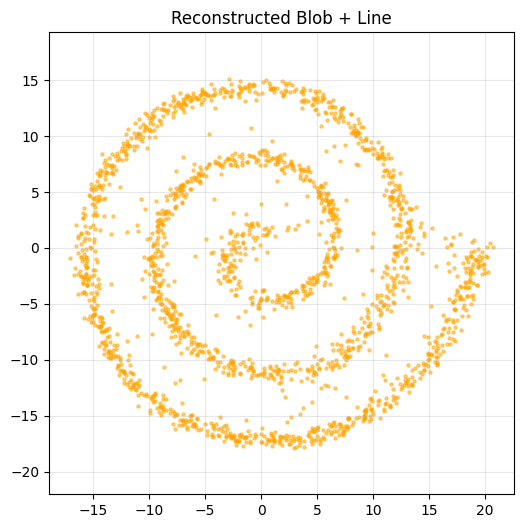

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScoreNet().to(device)

print("開始訓練 Score Model...")
T=10
steps=10000
train(model, beta=beta, sigma=5.0, T=T, steps=steps)

print("訓練完成，正在從雜訊還原數據...")
dt=T/steps
generated_data = reverse_sample(model, n_samples=2000, beta=beta, sigma=5.0, T=T, dt=dt)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
samples = generated_data.cpu().numpy()
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5, color='orange')
plt.title("Reconstructed Blob + Line")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

---

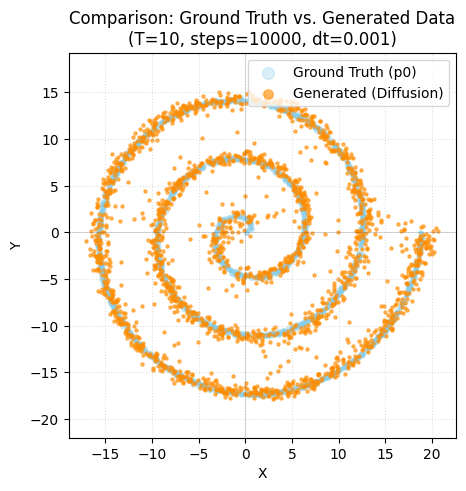

In [ ]:
gt_data = sample_p0_mix(n_points=2500)
if isinstance(gt_data, torch.Tensor):
    gt_data = gt_data.cpu().numpy()

gen_data = generated_data.cpu().numpy()
plt.figure(figsize=(5, 5))
plt.scatter(gt_data[:, 0], gt_data[:, 1], 
            color='skyblue', s=8, alpha=0.3, label='Ground Truth (p0)')
plt.scatter(gen_data[:, 0], gen_data[:, 1], 
            color='darkorange', s=5, alpha=0.6, label='Generated (Diffusion)')
plt.axhline(0, color='black', lw=0.5, alpha=0.2)
plt.axvline(0, color='black', lw=0.5, alpha=0.2)
T=10             ##########><<<<<<<<<<<<<<
steps=10000
plt.title(f"Comparison: Ground Truth vs. Generated Data\n(T={T}, steps={steps}, dt={T/steps:.3f})")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(markerscale=3)
plt.axis('equal') 
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()

## 畫向量圖

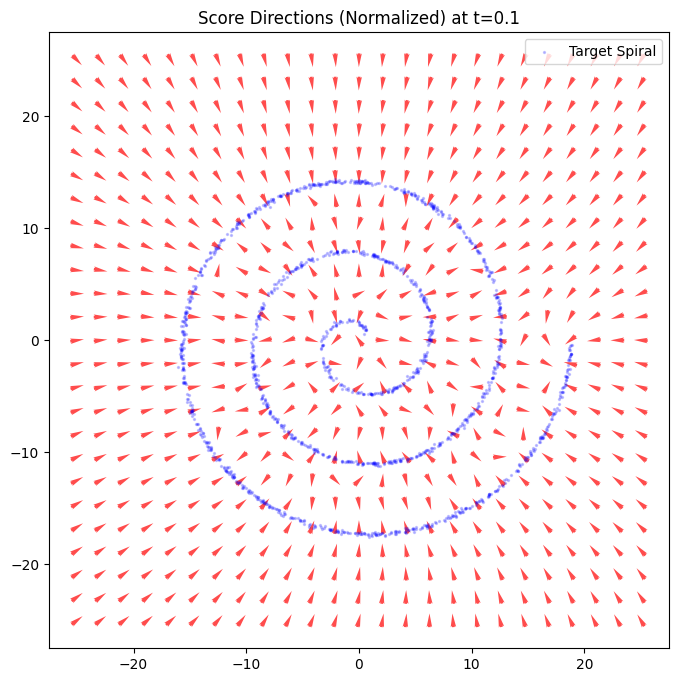

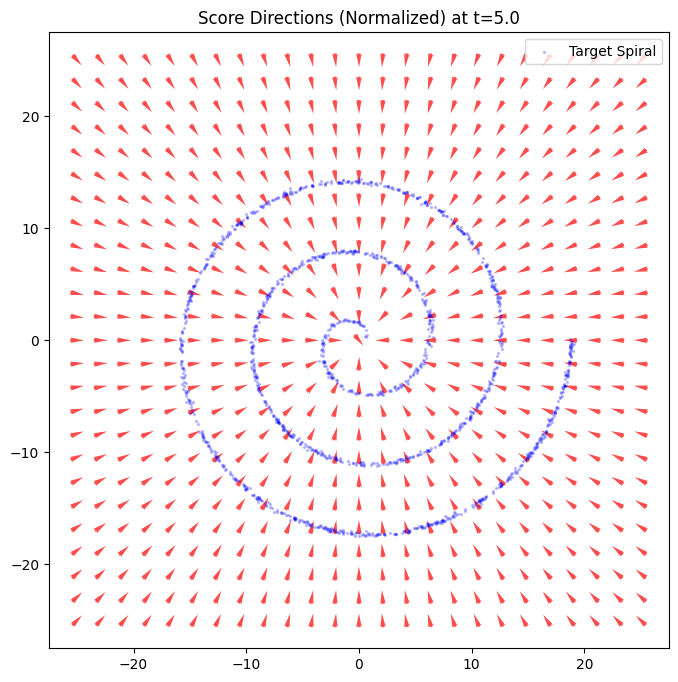

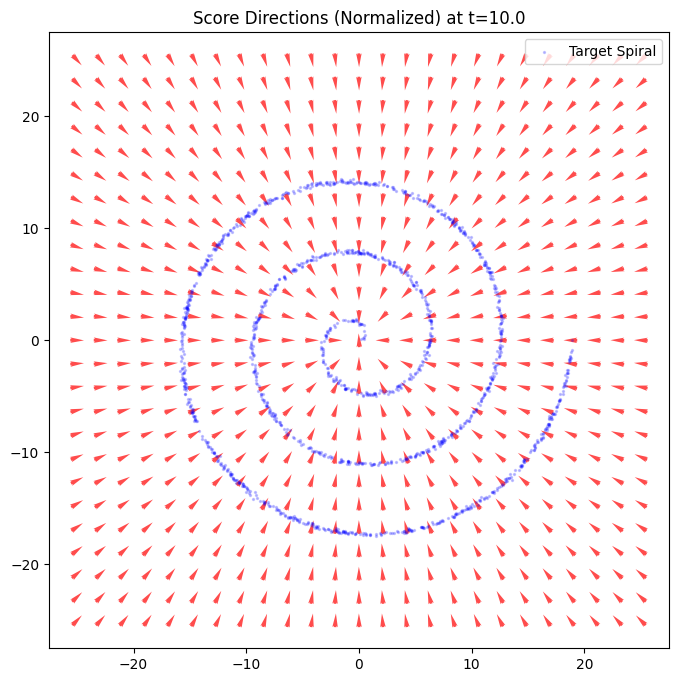

In [21]:
def plot_score_field_bold(model, beta=1.0, sigma=5.0, t_val=0.1):
    model.eval()
    # 1. 建立網格
    x_range = np.linspace(-25, 25, 25) # 密度不要太高，否則會塞在一起
    y_range = np.linspace(-25, 25, 25)
    X, Y = np.meshgrid(x_range, y_range)
    grid_tensor = torch.tensor(np.stack([X.flatten(), Y.flatten()], axis=1), dtype=torch.float32).to(device)
    
    with torch.no_grad():
        t_tensor = torch.full((grid_tensor.shape[0],), t_val).to(device)
        eps_pred = model(grid_tensor, t_tensor).cpu().numpy()
    
    # 計算 Score 方向 (負號是因為 score = -eps/sigma)
    U, V = -eps_pred[:, 0].reshape(X.shape), -eps_pred[:, 1].reshape(Y.shape)
    
    # --- 關鍵修正：歸一化，讓所有箭頭長度一致 ---
    norm = np.sqrt(U**2 + V**2) + 1e-9
    U_norm, V_norm = U / norm, V / norm

    plt.figure(figsize=(8, 8))
    
    # 畫出箭頭
    # scale: 數值越小，箭頭越大 (因為它是除數)
    # width: 箭頭身軀的寬度
    # headwidth: 箭頭頭部的寬度
    Q = plt.quiver(X, Y, U_norm, V_norm, 
                   color='red', 
                   alpha=0.7, 
                   pivot='mid',    # 箭頭中心對準網格點
                   scale=45,       # 調整這個數字直到箭頭大小滿意 (越小箭頭越長)
                   width=0.005,    # 箭頭寬度
                   headwidth=2)    # 箭頭頭部寬度
    
    # 背景畫出螺旋
    gt = sample_p0_mix(1500)
    plt.scatter(gt[:, 0], gt[:, 1], s=2, color='blue', alpha=0.2, label='Target Spiral')
    
    plt.title(f"Score Directions (Normalized) at t={t_val}")
    plt.legend()
    plt.show()

# 重新跑一次
for t in [0.1, 5.0, 10.0]:
    plot_score_field_bold(model, beta=beta, sigma=sigma, t_val=t)